# Overbooking - Newsvendor

[https://en.wikipedia.org/wiki/Newsvendor_model](https://en.wikipedia.org/wiki/Newsvendor_model)

--- DISCRETE OPTIMIZATION RESULTS ---
ECONOMY (400 Seats): Sell 426 tickets (Overbook by 26). Min Expected Cost: $879.57
BUSINESS (100 Seats): Sell 133 tickets (Overbook by 33). Min Expected Cost: $1977.22


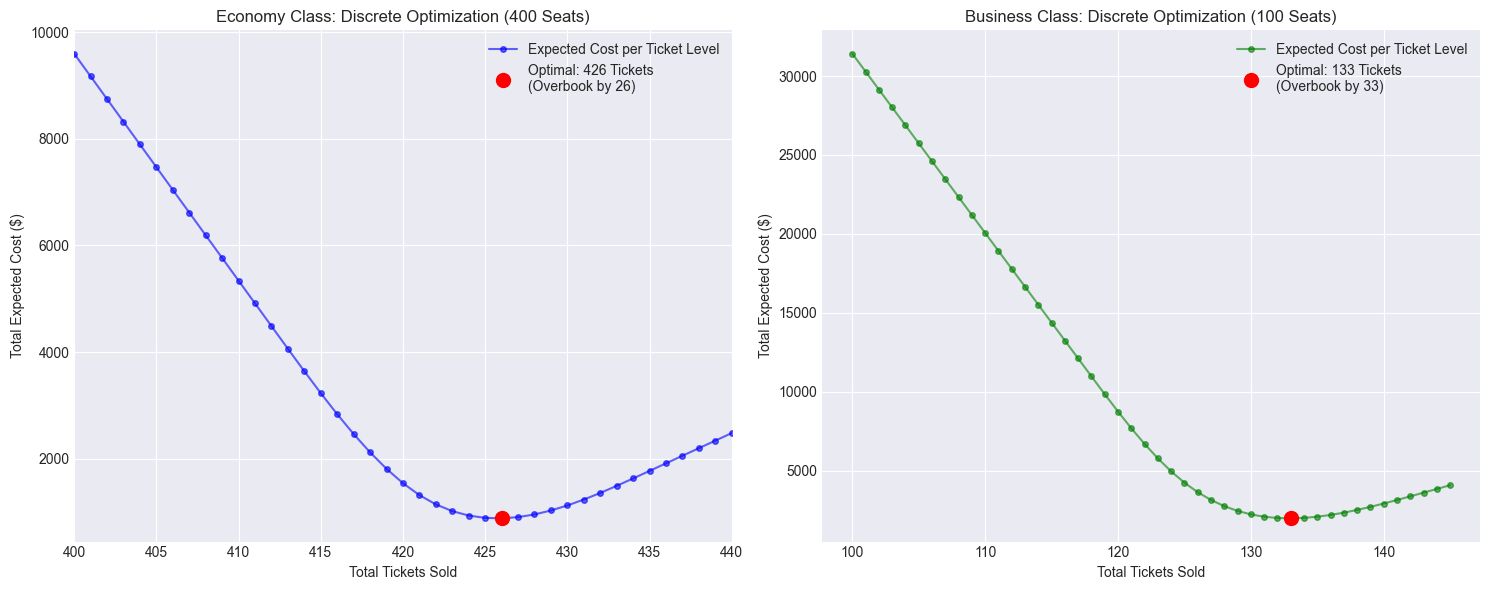

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import triang
from scipy.integrate import quad

# --- Helper Function for Discrete Expected Cost ---
def expected_cost_discrete(B, C, Cu, Co, dist, min_val, max_val):
    """
    B: Total Tickets Sold (Integer)
    C: Actual Seat Capacity (Integer)
    Cu: Cost of Underage (Empty Seat)
    Co: Cost of Overage (Bumped Passenger)
    """
    # Threshold no-show rate where show-ups exactly equal capacity
    r_star = 1 - (C / B)
    
    # If threshold is below our minimum no-show rate, we NEVER bump anyone
    if r_star <= min_val:
        cost, _ = quad(lambda r: Cu * (C - B*(1-r)) * dist.pdf(r), min_val, max_val)
        return cost
        
    # If threshold is above our maximum no-show rate, we ALWAYS bump someone
    elif r_star >= max_val:
        cost, _ = quad(lambda r: Co * (B*(1-r) - C) * dist.pdf(r), min_val, max_val)
        return cost
        
    # Otherwise, calculate the mix of expected bumping and expected empty seats
    else:
        expected_overage, _ = quad(lambda r: Co * (B*(1-r) - C) * dist.pdf(r), min_val, r_star)
        expected_underage, _ = quad(lambda r: Cu * (C - B*(1-r)) * dist.pdf(r), r_star, max_val)
        return expected_overage + expected_underage

# --- 1. ECONOMY CLASS SETUP ---
cap_econ = 400  # Assumed capacity based on the 440 max axis
Cu_econ = 450
Co_econ = 150
min_e, mode_e, max_e = 0.03, 0.05, 0.08

dist_econ = triang((mode_e - min_e)/(max_e - min_e), loc=min_e, scale=(max_e - min_e))

# Test booking levels from Capacity up to exactly 440
tickets_econ = list(range(cap_econ, 441))
costs_econ = [expected_cost_discrete(b, cap_econ, Cu_econ, Co_econ, dist_econ, min_e, max_e) for b in tickets_econ]

opt_tickets_econ = tickets_econ[np.argmin(costs_econ)]
min_cost_econ = min(costs_econ)

# --- 2. BUSINESS CLASS SETUP ---
cap_biz = 100
Cu_biz = 1450
Co_biz = 300
min_b, mode_b, max_b = 0.15, 0.20, 0.30

dist_biz = triang((mode_b - min_b)/(max_b - min_b), loc=min_b, scale=(max_b - min_b))

# Test booking levels from Capacity up to 145
tickets_biz = list(range(cap_biz, cap_biz + 46))
costs_biz = [expected_cost_discrete(b, cap_biz, Cu_biz, Co_biz, dist_biz, min_b, max_b) for b in tickets_biz]

opt_tickets_biz = tickets_biz[np.argmin(costs_biz)]
min_cost_biz = min(costs_biz)

# --- Output Results to Console ---
print("--- DISCRETE OPTIMIZATION RESULTS ---")
print(f"ECONOMY (400 Seats): Sell {opt_tickets_econ} tickets (Overbook by {opt_tickets_econ - cap_econ}). Min Expected Cost: ${min_cost_econ:.2f}")
print(f"BUSINESS (100 Seats): Sell {opt_tickets_biz} tickets (Overbook by {opt_tickets_biz - cap_biz}). Min Expected Cost: ${min_cost_biz:.2f}")

# --- Plotting ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Economy
ax1.plot(tickets_econ, costs_econ, 'bo-', alpha=0.6, markersize=4, label='Expected Cost per Ticket Level')
ax1.plot(opt_tickets_econ, min_cost_econ, 'ro', markersize=10, 
         label=f'Optimal: {opt_tickets_econ} Tickets\n(Overbook by {opt_tickets_econ - cap_econ})')
ax1.set_title('Economy Class: Discrete Optimization (400 Seats)')
ax1.set_xlabel('Total Tickets Sold')
ax1.set_ylabel('Total Expected Cost ($)')
ax1.set_xlim(cap_econ, 440) # explicitly lock the x-axis to 440
ax1.legend()

# Plot 2: Business
ax2.plot(tickets_biz, costs_biz, 'go-', alpha=0.6, markersize=4, label='Expected Cost per Ticket Level')
ax2.plot(opt_tickets_biz, min_cost_biz, 'ro', markersize=10, 
         label=f'Optimal: {opt_tickets_biz} Tickets\n(Overbook by {opt_tickets_biz - cap_biz})')
ax2.set_title('Business Class: Discrete Optimization (100 Seats)')
ax2.set_xlabel('Total Tickets Sold')
ax2.set_ylabel('Total Expected Cost ($)')
ax2.legend()

plt.tight_layout()
plt.show()

## Newsvendor: The Critical Ratio

The foundation of the Newsvendor model is the **Critical Ratio (CR)**. This ratio dictates the optimal service level—in this case, the target percentile of the no-show distribution we should aim for to minimize expected financial losses.

The general formula for the Critical Ratio balances the cost of having too few passengers against the cost of having too many:

$$ CR = \frac{C_u}{C_u + C_o} $$

Where:
* **$C_u$** = Cost of Underage (the cost of flying an empty seat)
* **$C_o$** = Cost of Overage (the compensation cost to bump a passenger)

---

### 1. Economy Class Calculation
For the Economy cabin, the cost of an empty seat ($450) is three times higher than the cost of bumping someone ($150). 

$$ CR_{econ} = \frac{450}{450 + 150} = \frac{450}{600} = 0.75 $$

**Interpretation:** The airline should set their ticket sales to hit the **75th percentile** of the Economy no-show distribution. 

### 2. Business Class Calculation
For the Business cabin, the cost of an empty seat is much steeper ($1,450), while the bumping penalty is $30    0.

$$ CR_{biz} = \frac{1450}{1450 + 300} = \frac{1450}{1750} \approx 0.8286 $$

**Interpretation:** The airline should set their ticket sales to hit the **82.86th percentile** of the Business no-show distribution. 

> 💡 **Takeaway:** Because empty seats are significantly more expensive than bumping passengers in *both* cabins, the critical ratios are high ($> 0.50$). This mathematically justifies an aggressive overbooking strategy to protect revenue.

In [5]:
# Define Economy parameters: c_shape is (mode-min)/(max-min)
a, c, b = 0.03, 0.05, 0.08
c_shape = (c - a) / (b - a)
economy_seats = 400

# Create the distribution
dist = triang(c=c_shape, loc=a, scale=(b - a))

# Find the 75th percentile
percentile_75 = dist.ppf(0.75)

print(f"The 75th percentile is: {percentile_75:.4f}, seats sold = {economy_seats / (1 - percentile_75):.0f}")

# Define Business parameters: c_shape is (mode-min)/(max-min)
a, c, b = 0.15, 0.20, 0.30
c_shape = (c - a) / (b - a)
business_seats = 100

# Create the distribution
dist = triang(c=c_shape, loc=a, scale=(b - a))

# Find the 82.86th percentile
percentile_8286 = dist.ppf(0.8286)

print(f"The 82.86th percentile is: {percentile_8286:.4f}, seats sold = {business_seats / (1 - percentile_8286):.0f}")


The 75th percentile is: 0.0606, seats sold = 426
The 82.86th percentile is: 0.2493, seats sold = 133
